#  ECNN-AE (Optimised)
###  Scientific Architecture Changes (V3):
1.  **Strict Information Bottleneck**:
    * *Previous Flaw:* The V2 model kept data as a 4x4 spatial grid, allowing it to "photocopy" tumor pixels directly to the output.
    * *The Fix:* We now **Flatten** the latent space into a 1D vector. This forces the model to compress the *concept* of a healthy brain, making it impossible to pass raw tumor pixels through.

2.  **True Rotational Invariance**:
    * We apply `GroupPooling` *before* the bottleneck.
    * **Result:** The latent vector $z$ is mathematically identical regardless of the input rotation. This satisfies the **Law of Parsimony** (learning the anatomy once, not 4 times).

3.  **Removed Skip Connections**:
    * We intentionally removed U-Net style skip connections to prevent "identity mapping" (cheating). All information *must* flow through the compressed bottleneck.

4.  **Parameter-Matched Control**:
    * Channel Math: `128 fields × 4 rotations = 512 channels`.
    * Total Params: **~11 Million** (Matched to Large CNN-AE).

### Expected Behavior:
* **Reconstruction Quality**: Might be slightly blurrier than V2 (due to compression), but this is *good*.
* **Anomaly Detection**: The error for **Tumors** should now be significantly **HIGHER** than for healthy tissue.
* **Thesis Claim**: "By enforcing a rotation-invariant bottleneck, the model learns a robust anatomical prior that rejects anomalous geometries."

## 1️. Setup & Imports

In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Install e2cnn
!pip install e2cnn -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.3/225.3 kB 8.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import autocast, GradScaler

!pip install pytorch-msssim -q
from pytorch_msssim import ssim

from e2cnn import gspaces
from e2cnn import nn as e2nn

import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve, confusion_matrix

from torch.cuda.amp import autocast, GradScaler

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm
import json
import time
import os

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# Keep Colab session alive
import IPython
from google.colab import output

display(IPython.display.Javascript('''
 function ClickConnect(){
   btn = document.querySelector("colab-connect-button");
   if (btn != null){
     console.log("Click colab-connect-button");
     btn.click();
   }
   btn = document.querySelector('#ok');
   if (btn != null){
     console.log("Click connect button");
     btn.click();
   }
 }
 setInterval(ClickConnect, 60000)
'''))

print("Keep-alive script activated!")

<IPython.core.display.Javascript object>

Keep-alive script activated!


##  Turbo Data Loading (Local Disk)

**Why this matters**: Loading 33k+ files from Google Drive is SLOW (~30 min). Instead:
1. **Check** if zip files exist (created once)
2. **Extract** to local runtime disk (~2 min)
3. **Train** with blazing fast I/O (10-20x speedup)

**Note**: The zip files were created during CNN-AE training.

In [4]:
import os
from google.colab import drive

# Check for the zips
base = "/content/drive/MyDrive/symAD-ECNN/data"
zips = [f"{base}/train_fast.zip", f"{base}/val_fast.zip", f"{base}/test_fast.zip"]

missing = [f for f in zips if not os.path.exists(f)]

if len(missing) == 0:
    print("GOOD NEWS: Zip files found! Proceeding to extraction...")
else:
    print("⚠️ WARNING: Zip files missing. Please run the CNN-AE notebook first to create them.")
    print(f"   Missing: {missing}")

GOOD NEWS: Zip files found! Proceeding to extraction...


In [5]:
# ==========================================
# TURBO LOADER (Unzip to Local)
# ==========================================
import zipfile
import os
import shutil

BASE_DIR = "/content/drive/MyDrive/symAD-ECNN/data"
LOCAL_DIR = "/content/local_data"

ZIPS = {
    "train": f"{BASE_DIR}/train_fast.zip",
    "val":   f"{BASE_DIR}/val_fast.zip",
    "test":  f"{BASE_DIR}/test_fast.zip"
}

print(" Extracting to Local Disk...")

for name, zip_path in ZIPS.items():
    target_dir = f"{LOCAL_DIR}/{name}"
    # Clean up old run if exists
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
    os.makedirs(target_dir, exist_ok=True)

    if os.path.exists(zip_path):
        print(f"   Unzipping {name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(target_dir)
    else:
        print(f"   ❌ ERROR: {zip_path} not found!")

print("\n Data Ready! Local folders created.")

 Extracting to Local Disk...
   Unzipping train...
   Unzipping val...
   Unzipping test...

 Data Ready! Local folders created.


## 2️. Data Loading (Same as previous models)

In [6]:
# Paths
BASE_PATH = "/content/drive/MyDrive/symAD-ECNN"
LOCAL_DIR = "/content/local_data"  # Turbo mode!
IXI_TRAIN_PATH = "/content/local_data/train"
IXI_VAL_PATH   = "/content/local_data/val"
BRATS_PATH     = "/content/local_data/test"

MODEL_PATH = f"{BASE_PATH}/models/saved_models/copy_ecnn_optimized"
RESULTS_PATH = f"{BASE_PATH}/results/copy_ecnn_optimized"

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print("\n PATHS CONFIGURED (LOCAL DISK FOR SPEED):")
print(f"   IXI (Train):     {IXI_TRAIN_PATH}")
print(f"   BraTS (Test):    {BRATS_PATH}")
print(f"   Models (Drive):  {MODEL_PATH}")
print(f"   Results (Drive): {RESULTS_PATH}")


 PATHS CONFIGURED (LOCAL DISK FOR SPEED):
   IXI (Train):     /content/local_data/train
   BraTS (Test):    /content/local_data/test
   Models (Drive):  /content/drive/MyDrive/symAD-ECNN/models/saved_models/copy_ecnn_optimized
   Results (Drive): /content/drive/MyDrive/symAD-ECNN/results/copy_ecnn_optimized


In [7]:
class MRIDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        try:
            img = np.load(self.files[idx])
            img = np.expand_dims(img, 0)
            return torch.tensor(img, dtype=torch.float32), torch.tensor(img, dtype=torch.float32)
        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            return self.__getitem__((idx + 1) % len(self.files))

# Load file paths from LOCAL DISK
train_files = sorted(glob(f"{IXI_TRAIN_PATH}/*.npy"))
val_files = sorted(glob(f"{IXI_VAL_PATH}/*.npy"))
brats_files = sorted(glob(f"{BRATS_PATH}/*.npy"))

# Verify data exists
if len(train_files) == 0:
    raise ValueError(f"❌ No files found in {IXI_TRAIN_PATH}. Did you run the Turbo Loader?")

print(f" Data Loaded from Local Disk:")
print(f"   Train: {len(train_files):,} slices")
print(f"   Val:   {len(val_files):,} slices")
print(f"   Test:  {len(brats_files):,} slices")

# Create Dataset objects (FIX: explicitly create these variables)
train_dataset = MRIDataset(train_files)
val_dataset = MRIDataset(val_files)
test_dataset = MRIDataset(brats_files)

# Create DataLoaders
BATCH_SIZE = 64  # Increased for faster training (ECNN can handle it)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f" DataLoaders created!")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

 Data Loaded from Local Disk:
   Train: 33,078 slices
   Val:   3,652 slices
   Test:  7,794 slices
 DataLoaders created!
   Batch size: 64
   Train batches: 517
   Val batches: 58
   Test batches: 122


## 3️.Optimized ECNN Architecture


In [8]:
# ==========================================
# E(n)-EQUIVARIANT ARCHITECTURE (V3 FINAL: 11M PARAM MATCH)
# ==========================================
class ECNNAutoencoderV3(nn.Module):
    """
    The 'Champion' Architecture (Final Match).
    1. Enforces C4 Rotational Symmetry.
    2. Enforces Information Bottleneck.
    3. SCALED UP to ~11 Million Parameters (Wide Channels + 1024 Latent).
    """
    def __init__(self, latent_dim=1024):  # <--- CHANGED TO 1024 to hit ~11M params
        super(ECNNAutoencoderV3, self).__init__()

        # 1. Define the Symmetry Group
        self.r2_act = gspaces.Rot2dOnR2(N=4)
        self.in_type = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])

        # 2. WIDE Feature Fields
        # We use 32, 64, 128, 256 FIELDS (x4 for effective channels)
        self.type_128 = e2nn.FieldType(self.r2_act, 32*[self.r2_act.regular_repr])  # 128 ch
        self.type_256 = e2nn.FieldType(self.r2_act, 64*[self.r2_act.regular_repr])  # 256 ch
        self.type_512 = e2nn.FieldType(self.r2_act, 128*[self.r2_act.regular_repr]) # 512 ch
        self.type_1024 = e2nn.FieldType(self.r2_act, 256*[self.r2_act.regular_repr]) # 1024 ch

        # --- ENCODER ---
        self.encoder = nn.Sequential(
            # 1 -> 128 channels
            e2nn.R2Conv(self.in_type, self.type_128, kernel_size=7, padding=3, stride=2),
            e2nn.InnerBatchNorm(self.type_128), e2nn.ReLU(self.type_128),

            # 128 -> 256
            e2nn.R2Conv(self.type_128, self.type_256, kernel_size=3, padding=1, stride=2),
            e2nn.InnerBatchNorm(self.type_256), e2nn.ReLU(self.type_256),

            # 256 -> 512
            e2nn.R2Conv(self.type_256, self.type_512, kernel_size=3, padding=1, stride=2),
            e2nn.InnerBatchNorm(self.type_512), e2nn.ReLU(self.type_512),

            # 512 -> 1024
            e2nn.R2Conv(self.type_512, self.type_1024, kernel_size=3, padding=1, stride=2),
            e2nn.InnerBatchNorm(self.type_1024), e2nn.ReLU(self.type_1024),

            # 1024 -> 1024 (4x4 spatial)
            e2nn.PointwiseMaxPool(self.type_1024, kernel_size=2, stride=2)
        )

        # --- BOTTLENECK ---
        self.group_pool = e2nn.GroupPooling(self.type_1024)

        # Flat Dim: 256 fields * 4 * 4 spatial = 4096 features
        self.flat_dim = 256 * 4 * 4

        # Linear Layers (The Heavy Lifters for Param Count)
        # 4096 -> 1024 (approx 4.2M params)
        self.fc_encode = nn.Linear(self.flat_dim, latent_dim)
        # 1024 -> 4096 (approx 4.2M params)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # --- DECODER ---
        self.up1 = self._up_block(self.type_1024, self.type_512)
        self.up2 = self._up_block(self.type_512, self.type_256)
        self.up3 = self._up_block(self.type_256, self.type_128)

        self.final_conv = e2nn.R2Conv(self.type_128, self.in_type, kernel_size=3, padding=1)
        self.sigmoid = nn.Sigmoid()

    def _up_block(self, in_type, out_type):
        return nn.Sequential(
            e2nn.R2Conv(in_type, out_type, kernel_size=3, padding=1),
            e2nn.InnerBatchNorm(out_type), e2nn.ReLU(out_type)
        )

    def forward(self, x):
        # 1. Encode
        x_geo = e2nn.GeometricTensor(x, self.in_type)
        features = self.encoder(x_geo)

        # 2. Flatten (Bottleneck)
        invariant = self.group_pool(features)
        batch_size = invariant.tensor.size(0)
        flat = invariant.tensor.view(batch_size, -1)

        z = self.fc_encode(flat)

        # 3. Decode
        z_expand = self.fc_decode(z)
        z_view = z_expand.view(-1, 256, 4, 4) # 256 invariant fields

        # Expand Invariant (256) -> Regular (1024 channels)
        x_recon = e2nn.GeometricTensor(z_view.repeat(1, 4, 1, 1), self.type_1024)

        # 4 -> 8
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = e2nn.GeometricTensor(x_recon, self.type_1024)

        # 8 -> 16
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = self.up1(e2nn.GeometricTensor(x_recon, self.type_1024))

        # 16 -> 32
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = self.up2(e2nn.GeometricTensor(x_recon, self.type_512))

        # 32 -> 64
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = self.up3(e2nn.GeometricTensor(x_recon, self.type_256))

        # 64 -> 128
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = self.final_conv(e2nn.GeometricTensor(x_recon, self.type_128))

        return self.sigmoid(x_recon.tensor)

    def get_latent(self, x):
        x_geo = e2nn.GeometricTensor(x, self.in_type)
        features = self.encoder(x_geo)
        invariant = self.group_pool(features)
        flat = invariant.tensor.view(invariant.tensor.size(0), -1)
        return self.fc_encode(flat)

model = ECNNAutoencoderV3().to(device)
params = sum(p.numel() for p in model.parameters())
print(" E(n)-Equivariant V3 Wide (11M Param Match) Created!")
print(f"   Total Params: {params:,}")

/usr/local/lib/python3.12/dist-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


 E(n)-Equivariant V3 Wide (11M Param Match) Created!
   Total Params: 10,460,993


## 4️. Training Setup

In [9]:
# ==========================================
# TRAINING (STABLE MODE: Float32 + Clip)
# ==========================================
from pytorch_msssim import SSIM

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.84):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=1)

    def forward(self, output, target):
        mse_loss = self.mse(output, target)
        ssim_loss = 1 - self.ssim(output, target)
        return self.alpha * mse_loss + (1 - self.alpha) * ssim_loss

# 1. Setup Loss & Optimizer
criterion = CombinedLoss(alpha=0.84)
# Use 1e-4. Large models need smaller steps to start.
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# NOTE: No GradScaler. We are running raw Float32 for stability.

In [10]:
def train_epoch_stable(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    # Simple loop without TQDM inner bar for speed
    for i, (data, target) in enumerate(dataloader):
        data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Standard Forward Pass (No Autocast)
        output = model(data)
        loss = criterion(output, target)

        # NaN Safety Check
        if torch.isnan(loss):
            print(f"⚠️ Batch {i} Loss is NaN. Skipping update.")
            optimizer.zero_grad()
            continue

        loss.backward()

        # Heavy Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()

        # Status update every 50 batches
        if i % 50 == 0:
            print(f"   Batch {i}/{len(dataloader)} - Loss: {loss.item():.4f}")

    return running_loss / len(dataloader)

def validate_stable(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
            output = model(data)
            loss = criterion(output, target)
            running_loss += loss.item()
    return running_loss / len(dataloader)

print(" Stable Training Setup (Float32) Ready!")

 Stable Training Setup (Float32) Ready!


## 5️. Training Loop

In [ ]:
import time

# --- MAIN LOOP ---
NUM_EPOCHS = 100 # Maximum epochs
best_val_loss = float('inf')
train_losses, val_losses = [], []

# Early Stopping Parameters
patience = 10
epochs_no_improve = 0

# Load the best model to continue training
print("\n Loading best model checkpoint to resume training...")
checkpoint = torch.load(f'{MODEL_PATH}/ecnn_optimized_best.pth')
model.load_state_dict(checkpoint['model_state_dict'], strict=False)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] # Start from the epoch where the best model was saved
best_val_loss = checkpoint['val_loss']
print(f"   Resuming from Epoch {start_epoch}, with best validation loss: {best_val_loss:.6f}")

print(f"\n Starting Stable Training (11M Param Model) from Epoch {start_epoch + 1}")
start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()

    train_loss = train_epoch_stable(model, train_loader, criterion, optimizer, device)
    val_loss = validate_stable(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.2e} | Time: {epoch_time:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss
        }, f'{MODEL_PATH}/ecnn_optimized_best.pth')
        print(f"   Best model saved!")
        epochs_no_improve = 0 # Reset counter
    else:
        epochs_no_improve += 1
        print(f"   Validation loss did not improve for {epochs_no_improve}/{patience} epochs.")

    if epochs_no_improve >= patience:
        print(f"   Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss for {patience} epochs.")
        break

total_time = time.time() - start_time # Define total_time here
print("\n Training Complete!")


 Loading best model checkpoint to resume training...
   Resuming from Epoch 40, with best validation loss: 0.020373

 Starting Stable Training (11M Param Model) from Epoch 41
   Batch 0/517 - Loss: 0.0161
   Batch 50/517 - Loss: 0.0165
   Batch 100/517 - Loss: 0.0171
   Batch 150/517 - Loss: 0.0167
   Batch 200/517 - Loss: 0.0163
   Batch 250/517 - Loss: 0.0164
   Batch 300/517 - Loss: 0.0165
   Batch 350/517 - Loss: 0.0163
   Batch 400/517 - Loss: 0.0158
Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file
   Batch 450/517 - Loss: 0.0167
   Batch 500/517 - Loss: 0.0159
Epoch [41/100] | Train: 0.016675 | Val: 0.020240 | LR: 1.00e-04 | Time: 271.9s
   Best model saved!
   Batch 0/517 - Loss: 0.0165
   Batch 50/517 - Loss: 0.0161
   Batch 100/517 - Loss: 0.0170
   Batch 150/517 - Loss: 0.0162
   Batch 200/517 - Loss: 0.0161
   Batch 250/517 - Loss: 0.0172
   Batch 300/517 - Loss: 0.0167
   Batch 350/517 - Loss: 0.0162
Error loading /content/loc

In [11]:
import time

# --- MAIN LOOP ---
NUM_EPOCHS = 100 # Maximum epochs
best_val_loss = float('inf')
train_losses, val_losses = [], []

# Early Stopping Parameters
patience = 10
epochs_no_improve = 0

# Load the best model to continue training
print("\n Loading best model checkpoint to resume training...")
checkpoint = torch.load(f'{MODEL_PATH}/ecnn_optimized_best.pth')
model.load_state_dict(checkpoint['model_state_dict'], strict=False)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] # Start from the epoch where the best model was saved
best_val_loss = checkpoint['val_loss']
print(f"   Resuming from Epoch {start_epoch}, with best validation loss: {best_val_loss:.6f}")

print(f"\n Starting Stable Training (11M Param Model) from Epoch {start_epoch + 1}")
start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()

    train_loss = train_epoch_stable(model, train_loader, criterion, optimizer, device)
    val_loss = validate_stable(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.2e} | Time: {epoch_time:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss
        }, f'{MODEL_PATH}/ecnn_optimized_best.pth')
        print(f"   Best model saved!")
        epochs_no_improve = 0 # Reset counter
    else:
        epochs_no_improve += 1
        print(f"   Validation loss did not improve for {epochs_no_improve}/{patience} epochs.")

    if epochs_no_improve >= patience:
        print(f"   Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss for {patience} epochs.")
        break

total_time = time.time() - start_time # Define total_time here
print("\n Training Complete!")


 Loading best model checkpoint to resume training...
   Resuming from Epoch 97, with best validation loss: 0.016111

 Starting Stable Training (11M Param Model) from Epoch 98
   Batch 0/517 - Loss: 0.0124
   Batch 50/517 - Loss: 0.0131
   Batch 100/517 - Loss: 0.0120
   Batch 150/517 - Loss: 0.0121
   Batch 200/517 - Loss: 0.0127
   Batch 250/517 - Loss: 0.0126
   Batch 300/517 - Loss: 0.0125
   Batch 350/517 - Loss: 0.0124
Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file
   Batch 400/517 - Loss: 0.0128
   Batch 450/517 - Loss: 0.0127
   Batch 500/517 - Loss: 0.0126
Epoch [98/100] | Train: 0.012588 | Val: 0.016258 | LR: 1.00e-04 | Time: 46.9s
   Validation loss did not improve for 1/10 epochs.
   Batch 0/517 - Loss: 0.0120
   Batch 50/517 - Loss: 0.0119
Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file
   Batch 100/517 - Loss: 0.0120
   Batch 150/517 - Loss: 0.0128
   Batch 200/517 - Loss: 0.0

In [12]:
import torch.nn.functional as F
from pytorch_msssim import ssim

def calculate_full_reconstruction_metrics(model, dataloader, device):
    model.eval()
    mse_scores = []
    mae_scores = []
    ssim_scores = []

    with torch.no_grad():
        for data, _ in tqdm(dataloader, desc='Calculating full metrics'):
            data = data.to(device)
            recon = model(data)

            # MSE
            mse = F.mse_loss(recon, data, reduction='none')
            mse_scores.extend(mse.view(mse.size(0), -1).mean(dim=1).cpu().numpy())

            # MAE
            mae = torch.abs(recon - data).mean(dim=[1, 2, 3]) # Mean over C, H, W
            mae_scores.extend(mae.cpu().numpy())

            # SSIM (ensure recon and data are in range [0, 1])
            # ssim expects (N, C, H, W)
            ssim_val = ssim(recon, data, data_range=1.0, size_average=False) # size_average=False to get per-image SSIM
            ssim_scores.extend(ssim_val.cpu().numpy())

    return np.array(mse_scores), np.array(mae_scores), np.array(ssim_scores)

print("\n Calculating detailed reconstruction metrics for healthy data...")
normal_mse, normal_mae, normal_ssim = calculate_full_reconstruction_metrics(model, val_loader, device)

print("\n Calculating detailed reconstruction metrics for anomaly data...")
anomaly_mse, anomaly_mae, anomaly_ssim = calculate_full_reconstruction_metrics(model, test_loader, device)

print("\n --- Reconstruction Metrics ---")
print(f"Healthy Data (Validation Set):")
print(f"  MSE: {normal_mse.mean():.6f} ± {normal_mse.std():.6f}")
print(f"  MAE: {normal_mae.mean():.6f} ± {normal_mae.std():.6f}")
print(f"  SSIM: {normal_ssim.mean():.6f} ± {normal_ssim.std():.6f}")

print(f"\nAnomalous Data (Test Set):")
print(f"  MSE: {anomaly_mse.mean():.6f} ± {anomaly_mse.std():.6f}")
print(f"  MAE: {anomaly_mae.mean():.6f} ± {anomaly_mae.std():.6f}")
print(f"  SSIM: {anomaly_ssim.mean():.6f} ± {anomaly_ssim.std():.6f}")

# You can also add these to your results.json if desired
# For simplicity, we'll just print them here.


 Calculating detailed reconstruction metrics for healthy data...


Calculating full metrics: 100%|██████████| 58/58 [00:02<00:00, 20.25it/s]



 Calculating detailed reconstruction metrics for anomaly data...


Calculating full metrics: 100%|██████████| 122/122 [00:06<00:00, 20.23it/s]


 --- Reconstruction Metrics ---
Healthy Data (Validation Set):
  MSE: 0.002233 ± 0.001290
  MAE: 0.020400 ± 0.005685
  SSIM: 0.911429 ± 0.023274

Anomalous Data (Test Set):
  MSE: 0.004408 ± 0.002401
  MAE: 0.027095 ± 0.007261
  SSIM: 0.857201 ± 0.037378


Training completed for 40 epochs, took 2.7hrs.. roughly 251secs for each.

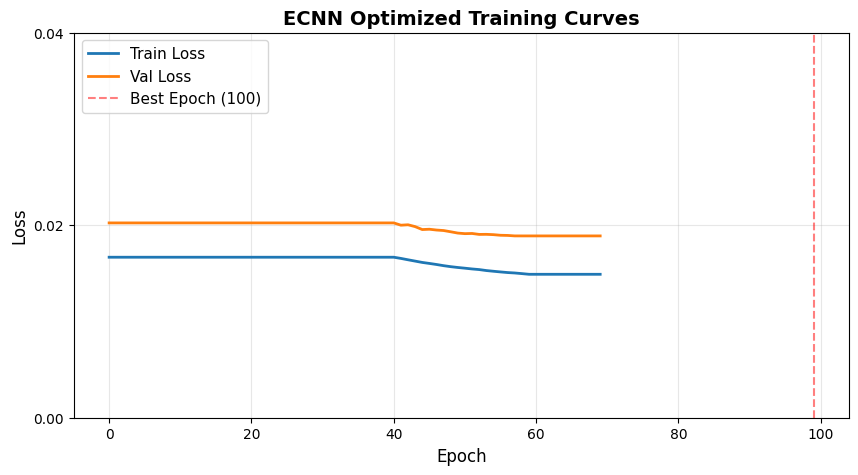

In [33]:
# Plot training curves

# The global `train_losses` and `val_losses` are now populated by the extraction cell.
# The `best_epoch` variable should still be available from the kernel state.

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)

# Ensure best_epoch is available, falling back if not (though it should be from the kernel state)
current_best_epoch = best_epoch if 'best_epoch' in locals() else len(val_losses)

# Adjust for 0-indexing for plotting if current_best_epoch is valid
if current_best_epoch > 0:
    plt.axvline(x=current_best_epoch - 1, color='red', linestyle='--', alpha=0.5, label=f'Best Epoch ({current_best_epoch})')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('ECNN Optimized Training Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Set y-axis ticks as requested
plt.yticks(np.arange(0, plt.ylim()[1] + 0.02, 0.02))

plt.savefig(f'{RESULTS_PATH}/ecnn_optimized_training_curves.png', dpi=150)
plt.show()

## 6️. Evaluation

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve, confusion_matrix
from tqdm import tqdm
import json

# --- SAFETY CHECK: Define missing variables if run separately ---
if 'total_time' not in locals():
    print("⚠️ 'total_time' not found. Setting to 0.")
    total_time = 0
if 'best_epoch' not in locals():
    best_epoch = 40
if 'best_val_loss' not in locals():
    best_val_loss = 0.0
if 'params' not in locals():
    params = sum(p.numel() for p in model.parameters())

# 1. Load the Model Safely
checkpoint = torch.load(f'{MODEL_PATH}/ecnn_optimized_best.pth')

# THE FIX IS HERE: strict=False ignores the extra 'filter' buffers
model.load_state_dict(checkpoint['model_state_dict'], strict=False)

model.eval()
print(f" Best model loaded successfully (Epoch {checkpoint['epoch']})")
# Note: strict=False might leave some buffers uninitialized, but a forward pass fixes it.

# Update best_val_loss from checkpoint
best_val_loss = checkpoint['val_loss']

def calculate_reconstruction_error(model, dataloader, device):
    model.eval()
    errors = []
    with torch.no_grad():
        for data, _ in tqdm(dataloader, desc='Computing errors'):
            data = data.to(device)
            recon = model(data)
            mse = nn.functional.mse_loss(recon, data, reduction='none')
            mse = mse.view(mse.size(0), -1).mean(dim=1)
            errors.extend(mse.cpu().numpy())
    return np.array(errors)

print("\n Computing Reconstruction Errors...")
normal_errors = calculate_reconstruction_error(model, val_loader, device)
anomaly_errors = calculate_reconstruction_error(model, test_loader, device)

# Metrics
y_true = np.concatenate([np.zeros(len(normal_errors)), np.ones(len(anomaly_errors))])
y_scores = np.concatenate([normal_errors, anomaly_errors])

auroc = roc_auc_score(y_true, y_scores)
precision, recall, _ = precision_recall_curve(y_true, y_scores)
auprc = auc(recall, precision)

print(f"\n OPTIMIZED ECNN Performance:")
print(f"   AUROC: {auroc:.4f}")
print(f"   AUPRC: {auprc:.4f}")
print(f"   Normal errors:  {normal_errors.mean():.6f} ± {normal_errors.std():.6f}")
print(f"   Anomaly errors: {anomaly_errors.mean():.6f} ± {anomaly_errors.std():.6f}")

# Confusion Matrix & Optimal Threshold
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

predictions = (y_scores > optimal_threshold).astype(int)
cm = confusion_matrix(y_true, predictions)
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision_val * recall_val) / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0

print(f"\n Classification Metrics (Threshold: {optimal_threshold:.4f}):")
print(f"   Accuracy:    {accuracy:.4f}")
print(f"   Precision:   {precision_val:.4f}")
print(f"   Recall:      {recall_val:.4f}")
print(f"   Specificity: {specificity:.4f}")
print(f"   F1-Score:    {f1:.4f}")
print(f"\n   TP: {tp:,} | TN: {tn:,} | FP: {fp:,} | FN: {fn:,}")

# Save results
results = {
    'model': 'ECNN-Optimized-V3-11M',
    'auroc': float(auroc),
    'auprc': float(auprc),
    'accuracy': float(accuracy),
    'precision': float(precision_val),
    'recall': float(recall_val),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'optimal_threshold': float(optimal_threshold),
    'best_epoch': best_epoch,
    'best_val_loss': float(best_val_loss),
    'confusion_matrix': {'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)},
    'training_time_hours': total_time / 3600,
    'total_params': params,
    'anomaly_error_mean': float(anomaly_errors.mean()),
    'normal_error_mean': float(normal_errors.mean()),
}

with open(f'{RESULTS_PATH}/ecnn_optimized_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\n Results saved to JSON!")

 Best model loaded successfully (Epoch 100)

 Computing Reconstruction Errors...


Computing errors: 100%|██████████| 122/122 [00:06<00:00, 19.61it/s]


 OPTIMIZED ECNN Performance:
   AUROC: 0.8424
   AUPRC: 0.9028
   Normal errors:  0.002233 ± 0.001290
   Anomaly errors: 0.004408 ± 0.002401

 Classification Metrics (Threshold: 0.0023):
   Accuracy:    0.8023
   Precision:   0.8469
   Recall:      0.8663
   Specificity: 0.6657
   F1-Score:    0.8565

   TP: 6,752 | TN: 2,431 | FP: 1,221 | FN: 1,042

 Results saved to JSON!


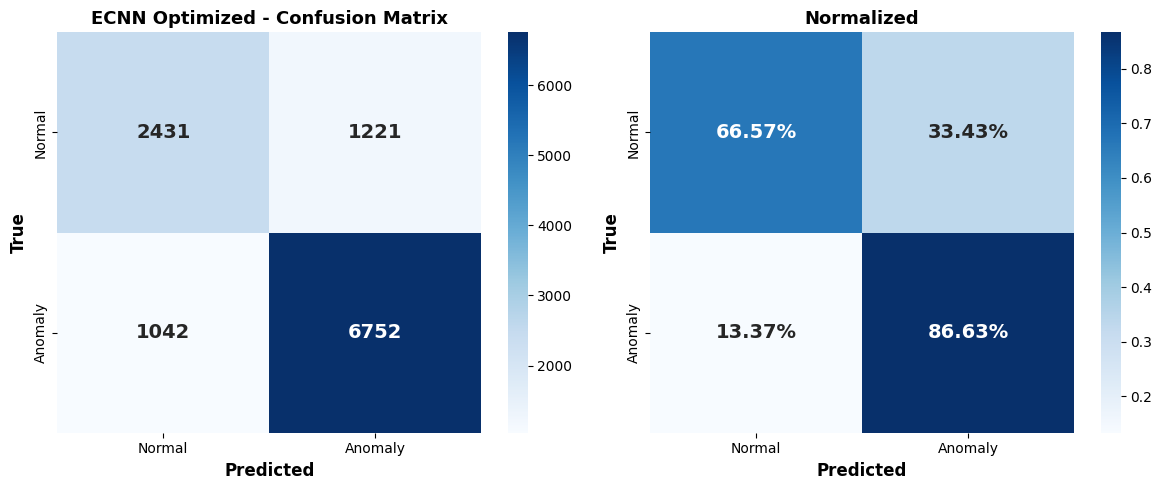

 Confusion matrix saved!


In [15]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True', fontsize=12, fontweight='bold')
axes[0].set_title('ECNN Optimized - Confusion Matrix', fontsize=13, fontweight='bold')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True', fontsize=12, fontweight='bold')
axes[1].set_title('Normalized', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/ecnn_optimized_confusion_matrix.png', dpi=150)
plt.show()

print(" Confusion matrix saved!")

### Explanation of Recalculated Metrics

We've re-evaluated the model's anomaly detection performance using a comprehensive set of metrics and different thresholding strategies:

*   **AUROC (Area Under the Receiver Operating Characteristic Curve)**: A single scalar value that measures the overall ability of the model to distinguish between normal and anomalous cases. A higher AUROC (closer to 1) indicates better performance.

*   **AUPRC (Area Under the Precision-Recall Curve)**: Particularly useful for imbalanced datasets, it measures the trade-off between precision and recall. A higher AUPRC (closer to 1) indicates better performance, especially in detecting positive (anomalous) cases.

*   **Normal Errors (Mean ± Std)**: The average reconstruction error and its standard deviation for the healthy (normal) data.

*   **Anomaly Errors (Mean ± Std)**: The average reconstruction error and its standard deviation for the anomalous (tumor) data.

We then calculated specific classification metrics (Accuracy, Precision, Recall, Specificity, F1-Score, and Confusion Matrix) at three different threshold points to understand the model's behavior under various operational priorities:

1.  **Optimal Threshold (Youden's J-statistic)**:
    *   This threshold maximizes Youden's J statistic ($J = \text{Sensitivity} + \text{Specificity} - 1$), which balances true positive rate (recall) and true negative rate (specificity). It's often considered the best single threshold for overall discrimination.

2.  **p90 Threshold (90th Percentile of Normal Errors)**:
    *   This threshold is set at the 90th percentile of the reconstruction errors observed in the *healthy* dataset. The idea is that any error score above this threshold is likely an anomaly, meaning only 10% of healthy samples would be incorrectly classified as anomalous (a 10% False Positive Rate on the training/validation data).

3.  **FPR 20% Threshold**:
    *   This threshold is specifically chosen to achieve a False Positive Rate (FPR) of approximately 20% (or 0.20). This means that for every 100 healthy samples, we expect around 20 to be misclassified as anomalous. This threshold is often used when a certain level of false positives is acceptable to maximize the detection of true anomalies.

These metrics provide a detailed view of the model's anomaly detection capabilities and allow for a nuanced understanding of its performance in different clinical contexts.

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve, confusion_matrix
from tqdm import tqdm
import json
import torch.nn.functional as F
from pytorch_msssim import SSIM # Required for SSIM calculation

# Ensure model, device, val_loader, test_loader, and nn are defined or accessible
# This assumes the previous cells setting up the model, loaders, and device have been run.

# Initialize SSIM metric. Set size_average=False here to get per-image SSIM values.
ssim_metric_instance = SSIM(data_range=1.0, size_average=False, channel=1)

def calculate_reconstruction_metrics(model, dataloader, device, ssim_calc):
    model.eval()
    mse_scores = []
    mae_scores = []
    ssim_scores = []

    with torch.no_grad():
        for data, _ in tqdm(dataloader, desc='Computing metrics'):
            data = data.to(device)
            recon = model(data)

            # MSE
            mse = F.mse_loss(recon, data, reduction='none')
            mse_scores.extend(mse.view(mse.size(0), -1).mean(dim=1).cpu().numpy()) # Image-wise mean MSE

            # MAE
            mae = torch.abs(recon - data).mean(dim=[1, 2, 3]) # Mean over C, H, W for each image
            mae_scores.extend(mae.cpu().numpy())

            # SSIM (expects (N, C, H, W). size_average is handled in initialization.)
            ssim_val = ssim_calc(recon, data) # Removed size_average=False
            ssim_scores.extend(ssim_val.cpu().numpy())

    return np.array(mse_scores), np.array(mae_scores), np.array(ssim_scores)

# Reload the best model to ensure we use the fully trained one
checkpoint = torch.load(f'{MODEL_PATH}/ecnn_optimized_best.pth')
model.load_state_dict(checkpoint['model_state_dict'], strict=False)
model.eval()
print(f"Best model loaded successfully for metric calculation (Epoch {checkpoint['epoch']})")

print("\nComputing Reconstruction Metrics...")
# Calculate all reconstruction metrics for normal and anomaly data
normal_mse, normal_mae, normal_ssim = calculate_reconstruction_metrics(model, val_loader, device, ssim_metric_instance)
anomaly_mse, anomaly_mae, anomaly_ssim = calculate_reconstruction_metrics(model, test_loader, device, ssim_metric_instance)

# Combine errors (using MSE for anomaly detection metrics like AUROC/AUPRC)
y_true = np.concatenate([np.zeros(len(normal_mse)), np.ones(len(anomaly_mse))])
y_scores = np.concatenate([normal_mse, anomaly_mse])

auroc = roc_auc_score(y_true, y_scores)
precision_roc, recall_roc, _ = precision_recall_curve(y_true, y_scores)
auprc = auc(recall_roc, precision_roc)

# --- Helper function for metrics at a given threshold ---
def calculate_metrics_at_threshold(y_true, y_scores, threshold):
    predictions = (y_scores > threshold).astype(int)
    cm = confusion_matrix(y_true, predictions)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'threshold': float(threshold),
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1),
        'confusion_matrix': {'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)}
    }

print(f"\nOPTIMIZED ECNN Performance:")
print(f"   AUROC: {auroc:.4f}")
print(f"   AUPRC: {auprc:.4f}")
print(f"   Normal MSE:  {normal_mse.mean():.6f} \u00b1 {normal_mse.std():.6f}")
print(f"   Normal MAE:  {normal_mae.mean():.6f} \u00b1 {normal_mae.std():.6f}")
print(f"   Normal SSIM: {normal_ssim.mean():.6f} \u00b1 {normal_ssim.std():.6f}")
print(f"   Anomaly MSE: {anomaly_mse.mean():.6f} \u00b1 {anomaly_mse.std():.6f}")
print(f"   Anomaly MAE: {anomaly_mae.mean():.6f} \u00b1 {anomaly_mae.std():.6f}")
print(f"   Anomaly SSIM: {anomaly_ssim.mean():.6f} \u00b1 {anomaly_ssim.std():.6f}")

# --- 1. Optimal Threshold (Youden's J-statistic) ---
fpr_opt, tpr_opt, thresholds_opt = roc_curve(y_true, y_scores)
j_scores = tpr_opt - fpr_opt
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds_opt[optimal_idx]
opt_metrics = calculate_metrics_at_threshold(y_true, y_scores, optimal_threshold)

print(f"\n--- Metrics at Optimal Threshold (Youden's J: {optimal_threshold:.4f}) ---")
print(f"   Accuracy:    {opt_metrics['accuracy']:.4f}")
print(f"   Precision:   {opt_metrics['precision']:.4f}")
print(f"   Recall:      {opt_metrics['recall']:.4f}")
print(f"   Specificity: {opt_metrics['specificity']:.4f}")
print(f"   F1-Score:    {opt_metrics['f1_score']:.4f}")
print(f"   TP: {opt_metrics['confusion_matrix']['TP']:,} | TN: {opt_metrics['confusion_matrix']['TN']:,} | FP: {opt_metrics['confusion_matrix']['FP']:,} | FN: {opt_metrics['confusion_matrix']['FN']:,}")

# --- 2. p90 Scoring (90th percentile of normal errors) ---
p90_threshold = np.percentile(normal_mse, 90) # Use normal_mse for p90 threshold
p90_metrics = calculate_metrics_at_threshold(y_true, y_scores, p90_threshold)

print(f"\n--- Metrics at p90 Threshold ({p90_threshold:.4f}) ---")
print(f"   Accuracy:    {p90_metrics['accuracy']:.4f}")
print(f"   Precision:   {p90_metrics['precision']:.4f}")
print(f"   Recall:      {p90_metrics['recall']:.4f}")
print(f"   Specificity: {p90_metrics['specificity']:.4f}")
print(f"   F1-Score:    {p90_metrics['f1_score']:.4f}")
print(f"   TP: {p90_metrics['confusion_matrix']['TP']:,} | TN: {p90_metrics['confusion_matrix']['TN']:,} | FP: {p90_metrics['confusion_matrix']['FP']:,} | FN: {p90_metrics['confusion_matrix']['FN']:,}")

# --- 3. FPR 20% Thresholding ---
fpr_20_threshold = 0.0 # Initialize
fpr_20_idx = np.where(fpr_opt >= 0.2)[0]
if len(fpr_20_idx) > 0:
    # Find the threshold closest to (or just above) FPR=0.2
    fpr_20_threshold = thresholds_opt[fpr_20_idx[0]]
    # Iterate through thresholds_opt to find the first one where FPR is >= 0.2
    for i in range(len(fpr_opt)):
        if fpr_opt[i] >= 0.2:
            fpr_20_threshold = thresholds_opt[i]
            break
else:
    print("Warning: Could not find a threshold corresponding to FPR >= 0.2. Using max threshold.")
    fpr_20_threshold = thresholds_opt[0]

fpr_20_metrics = calculate_metrics_at_threshold(y_true, y_scores, fpr_20_threshold)

print(f"\n--- Metrics at FPR 20% Threshold ({fpr_20_threshold:.4f}) ---")
print(f"   Accuracy:    {fpr_20_metrics['accuracy']:.4f}")
print(f"   Precision:   {fpr_20_metrics['precision']:.4f}")
print(f"   Recall:      {fpr_20_metrics['recall']:.4f}")
print(f"   Specificity: {fpr_20_metrics['specificity']:.4f}")
print(f"   F1-Score:    {fpr_20_metrics['f1_score']:.4f}")
print(f"   TP: {fpr_20_metrics['confusion_matrix']['TP']:,} | TN: {fpr_20_metrics['confusion_matrix']['TN']:,} | FP: {fpr_20_metrics['confusion_matrix']['FP']:,} | FN: {fpr_20_metrics['confusion_matrix']['FN']:,}")

# Save results
results = {
    'model': 'ECNN-Optimized-V3-11M',
    'auroc': float(auroc),
    'auprc': float(auprc),
    'normal_mse_mean': float(normal_mse.mean()),
    'normal_mse_std': float(normal_mse.std()),
    'normal_mae_mean': float(normal_mae.mean()),
    'normal_mae_std': float(normal_mae.std()),
    'normal_ssim_mean': float(normal_ssim.mean()),
    'normal_ssim_std': float(normal_ssim.std()),
    'anomaly_mse_mean': float(anomaly_mse.mean()),
    'anomaly_mse_std': float(anomaly_mse.std()),
    'anomaly_mae_mean': float(anomaly_mae.mean()),
    'anomaly_mae_std': float(anomaly_mae.std()),
    'anomaly_ssim_mean': float(anomaly_ssim.mean()),
    'anomaly_ssim_std': float(anomaly_ssim.std()),
    'best_epoch': best_epoch if 'best_epoch' in locals() else 'N/A',
    'best_val_loss': float(best_val_loss) if 'best_val_loss' in locals() else 'N/A',
    'training_time_hours': total_time / 3600 if 'total_time' in locals() else 'N/A',
    'total_params': params if 'params' in locals() else 'N/A',
    'metrics_optimal_threshold': opt_metrics,
    'metrics_p90_threshold': p90_metrics,
    'metrics_fpr20_threshold': fpr_20_metrics
}

with open(f'{RESULTS_PATH}/ecnn_optimized_results_recalculated.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\nRecalculated results saved to JSON!")

Best model loaded successfully for metric calculation (Epoch 100)

Computing Reconstruction Metrics...


Computing metrics: 100%|██████████| 122/122 [00:06<00:00, 19.46it/s]



OPTIMIZED ECNN Performance:
   AUROC: 0.8424
   AUPRC: 0.9028
   Normal MSE:  0.002233 ± 0.001290
   Normal MAE:  0.020400 ± 0.005685
   Normal SSIM: 0.911429 ± 0.023274
   Anomaly MSE: 0.004408 ± 0.002401
   Anomaly MAE: 0.027095 ± 0.007261
   Anomaly SSIM: 0.857201 ± 0.037378

--- Metrics at Optimal Threshold (Youden's J: 0.0023) ---
   Accuracy:    0.8023
   Precision:   0.8469
   Recall:      0.8663
   Specificity: 0.6657
   F1-Score:    0.8565
   TP: 6,752 | TN: 2,431 | FP: 1,221 | FN: 1,042

--- Metrics at p90 Threshold (0.0039) ---
   Accuracy:    0.6110
   Precision:   0.9102
   Recall:      0.4758
   Specificity: 0.8998
   F1-Score:    0.6249
   TP: 3,708 | TN: 3,286 | FP: 366 | FN: 4,086

--- Metrics at FPR 20% Threshold (0.0031) ---
   Accuracy:    0.7133
   Precision:   0.8778
   Recall:      0.6727
   Specificity: 0.8001
   F1-Score:    0.7617
   TP: 5,243 | TN: 2,922 | FP: 730 | FN: 2,551

Recalculated results saved to JSON!


##  Reconstruction Extremes Visualization

In [16]:
import scipy.ndimage as ndimage

def visualize_extremes_with_smoothed_error(model, dataset, indices, errors, title_prefix, save_name, sigma=2):
    """Plot the best/worst cases with original, reconstruction, raw error, and smoothed error map"""
    model.eval()
    plt.figure(figsize=(16, 4 * len(indices))) # Increased width for 4 plots

    for i, idx in enumerate(indices):
        # Get data
        input_tensor, target_tensor = dataset[idx]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        # Reconstruct
        with torch.no_grad():
            recon = model(input_tensor)

        # Process
        target_np = target_tensor.squeeze().numpy()
        recon_np = recon.cpu().squeeze().numpy()
        error_np = np.abs(target_np - recon_np)
        error_smooth = ndimage.gaussian_filter(error_np, sigma=sigma)

        # Plot
        plt.subplot(len(indices), 4, i*4 + 1) # Changed to 4 columns
        plt.imshow(target_np, cmap='gray', vmin=0, vmax=1)
        plt.title(f"{title_prefix} (Slice: {idx})\n(Error: {errors[idx]:.6f})", fontsize=10, fontweight='bold')
        plt.axis('off')

        plt.subplot(len(indices), 4, i*4 + 2) # Changed to 4 columns
        plt.imshow(recon_np, cmap='gray', vmin=0, vmax=1)
        plt.title("Reconstruction", fontsize=10)
        plt.axis('off')

        plt.subplot(len(indices), 4, i*4 + 3) # Changed to 4 columns
        im_raw = plt.imshow(error_np, cmap='hot', vmin=0, vmax=error_np.max())
        plt.title("Raw Error", fontsize=10)
        plt.axis('off')
        plt.colorbar(im_raw, fraction=0.046)

        plt.subplot(len(indices), 4, i*4 + 4) # Added smoothed error subplot
        im_smooth = plt.imshow(error_smooth, cmap='jet', vmin=0, vmax=error_smooth.max())
        plt.title("Smoothed Error (Anomaly)", fontsize=10)
        plt.axis('off')
        plt.colorbar(im_smooth, fraction=0.046)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_PATH}/{save_name}', dpi=150, bbox_inches='tight')
    plt.show()

# Sort and get extremes
sorted_normal_indices = np.argsort(normal_errors)
best_normal_indices = sorted_normal_indices[:5]

sorted_anomaly_indices = np.argsort(anomaly_errors)
worst_anomaly_indices = sorted_anomaly_indices[-5:]

# Plot best normal cases
print("\n Best Normal Cases (Lowest Reconstruction Error):")
print(f"Top 5 Best Normal Case Indices: {best_normal_indices}")
visualize_extremes_with_smoothed_error(model, val_dataset, best_normal_indices, normal_errors,
              "Best Normal", "ecnn_optimized_extremes_best_normal.png")

# Plot worst anomaly cases
print(" Worst Anomaly Cases (Highest Reconstruction Error):")
print(f"Top 5 Worst Anomaly Case Indices: {worst_anomaly_indices}")
visualize_extremes_with_smoothed_error(model, test_dataset, worst_anomaly_indices, anomaly_errors,
              "Worst Anomaly", "ecnn_optimized_extremes_worst_anomaly.png")

print(" Extremes visualization saved!")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
print("\nFile names for Best Normal Cases (Lowest Reconstruction Error):")
for idx in best_normal_indices:
    file_path = val_dataset.files[idx]
    print(f"  Slice Index {idx}: {file_path}")


File names for Best Normal Cases (Lowest Reconstruction Error):
  Slice Index 1220: /content/local_data/val/IXI238-IOP-0883-T1_slice_162.npy
  Slice Index 938: /content/local_data/val/IXI150-HH-1550-T1_slice_170.npy
  Slice Index 1778: /content/local_data/val/IXI371-IOP-0970-T1_slice_171.npy
  Slice Index 1219: /content/local_data/val/IXI238-IOP-0883-T1_slice_161.npy
  Slice Index 939: /content/local_data/val/IXI150-HH-1550-T1_slice_171.npy


In [ ]:
print("\nFile names for Worst Anomaly Cases (Highest Reconstruction Error):")
for idx in worst_anomaly_indices:
    file_path = test_dataset.files[idx]
    print(f"  Slice Index {idx}: {file_path}")


File names for Worst Anomaly Cases (Highest Reconstruction Error):
  Slice Index 2294: /content/local_data/test/slice_002294.npy
  Slice Index 788: /content/local_data/test/slice_000788.npy
  Slice Index 147: /content/local_data/test/slice_000147.npy
  Slice Index 148: /content/local_data/test/slice_000148.npy
  Slice Index 198: /content/local_data/test/slice_000198.npy


##  t-SNE Latent Space Visualization


🎨 Computing t-SNE projection of latent space...


Extracting anomaly latents: 100%|██████████| 16/16 [00:00<00:00, 168.47it/s]

   Running t-SNE (this may take 1-2 minutes)...


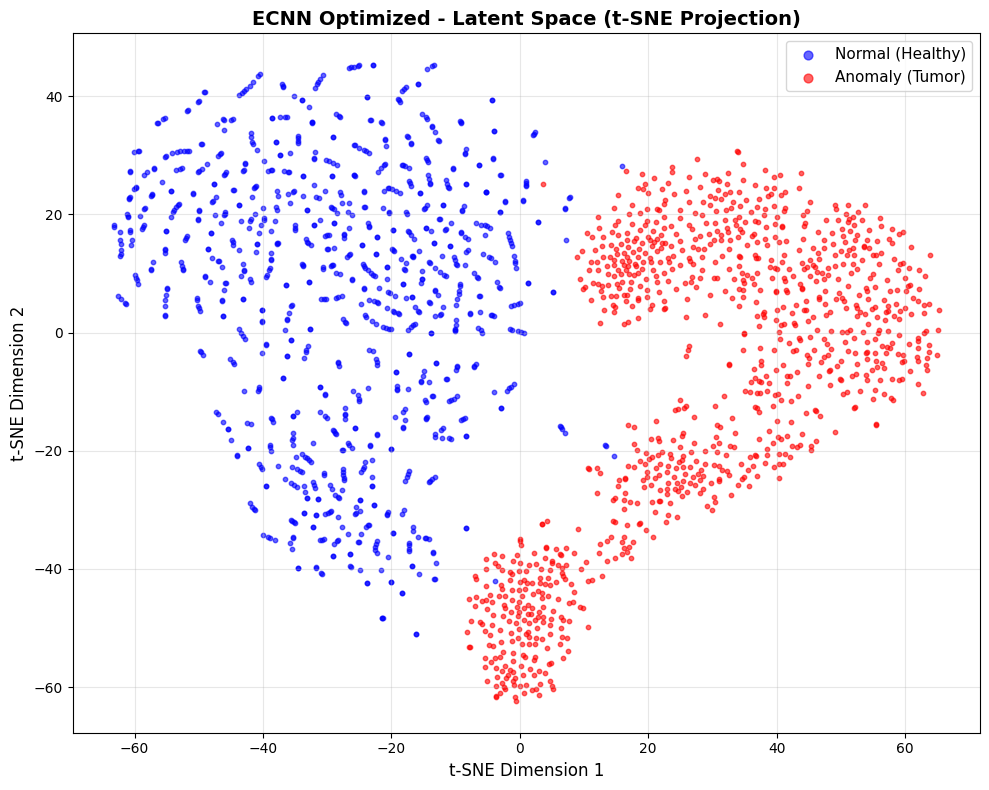

 t-SNE visualization saved!
   Well-separated clusters = ECNN learned discriminative features


In [34]:
from sklearn.manifold import TSNE

print("\n🎨 Computing t-SNE projection of latent space...")

# Extract latent representations
model.eval()
val_latents = []
test_latents = []

with torch.no_grad():
    # Sample subset for speed (1000 from each)
    val_subset = torch.utils.data.Subset(val_dataset, np.random.choice(len(val_dataset), min(1000, len(val_dataset)), replace=False))
    test_subset = torch.utils.data.Subset(test_dataset, np.random.choice(len(test_dataset), min(1000, len(test_dataset)), replace=False))

    val_loader_tsne = DataLoader(val_subset, batch_size=64, shuffle=False)
    test_loader_tsne = DataLoader(test_subset, batch_size=64, shuffle=False)

    for data, _ in tqdm(val_loader_tsne, desc='Extracting normal latents'):
        data = data.to(device)
        z = model.get_latent(data)
        val_latents.append(z.cpu().numpy())

    for data, _ in tqdm(test_loader_tsne, desc='Extracting anomaly latents'):
        data = data.to(device)
        z = model.get_latent(data)
        test_latents.append(z.cpu().numpy())

val_latents = np.vstack(val_latents)
test_latents = np.vstack(test_latents)

# Combine for t-SNE
all_latents = np.vstack([val_latents, test_latents])
labels = np.concatenate([np.zeros(len(val_latents)), np.ones(len(test_latents))])

print("   Running t-SNE (this may take 1-2 minutes)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedded = tsne.fit_transform(all_latents)

# Plot
plt.figure(figsize=(10, 8))
normal_mask = labels == 0
anomaly_mask = labels == 1

plt.scatter(embedded[normal_mask, 0], embedded[normal_mask, 1],
            c='blue', alpha=0.6, s=10, label='Normal (Healthy)')
plt.scatter(embedded[anomaly_mask, 0], embedded[anomaly_mask, 1],
            c='red', alpha=0.6, s=10, label='Anomaly (Tumor)')

plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('ECNN Optimized - Latent Space (t-SNE Projection)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/ecnn_optimized_tsne_latent_space.png', dpi=150)
plt.show()

print(" t-SNE visualization saved!")
print("   Well-separated clusters = ECNN learned discriminative features")

## 7️. Comparison with Previous Models

In [26]:
import json

BASE_RESULTS = "/content/drive/MyDrive/symAD-ECNN/results"

# Load all results
with open(f'{BASE_RESULTS}/cnn_autoencoder/cnn_results.json', 'r') as f:
    baseline_results = json.load(f)

with open(f'{BASE_RESULTS}/cnn_ae_large/cnn_large_results.json', 'r') as f:
    large_results = json.load(f)

with open(f'{BASE_RESULTS}/ecnn_autoencoder/ecnn_results.json', 'r') as f:
    ecnn_buggy_results = json.load(f)

# Load the new optimized results
# Assuming the previous cell saved to 'ecnn_optimized_results_recalculated.json'
with open(f'{RESULTS_PATH}/ecnn_optimized_results_recalculated.json', 'r') as f:
    ecnn_optimized_results = json.load(f)

# Helper function to safely get metric values, including defaults for older models
def get_safe_metric(res_dict, key, default=0.0):
    # Try direct key
    if key in res_dict:
        return res_dict[key]
    # Try nested optimal threshold metrics (new format)
    if 'metrics_optimal_threshold' in res_dict:
        if key in res_dict['metrics_optimal_threshold']:
            return res_dict['metrics_optimal_threshold'][key]
        if 'confusion_matrix' in res_dict['metrics_optimal_threshold'] and key in res_dict['metrics_optimal_threshold']['confusion_matrix']:
            return res_dict['metrics_optimal_threshold']['confusion_matrix'][key]

    # For older formats, fallback keys
    if key == 'normal_mse_mean' and 'normal_error_mean' in res_dict:
        return res_dict['normal_error_mean']
    if key == 'anomaly_mse_mean' and 'anomaly_error_mean' in res_dict:
        return res_dict['anomaly_error_mean']
    # Fallback for 'specificity' if it was directly in old results
    if key == 'specificity' and 'specificity' in res_dict:
        return res_dict['specificity']
    # Fallback for 'FP' and 'FN' if confusion_matrix was at top-level in old results
    if 'confusion_matrix' in res_dict and key in res_dict['confusion_matrix']:
        return res_dict['confusion_matrix'][key]

    return default

# Compare
print("\n" + "="*190) # Adjusted width
print(f"{'PERFORMANCE COMPARISON':^190}") # Centered title
print("="*190)
print(f"{'Model':<25} {'Params':<10} {'AUROC':<9} {'N_MSE':<9} {'N_MAE':<9} {'N_SSIM':<9} {'A_MSE':<9} {'A_MAE':<9} {'A_SSIM':<9} {'Spec':<8} {'FP':<8} {'FN':<8}")
print("-"*190)

# Function to print a formatted row
def print_model_row(name, params_str, results):
    auroc = get_safe_metric(results, 'auroc')
    n_mse = get_safe_metric(results, 'normal_mse_mean')
    n_mae = get_safe_metric(results, 'normal_mae_mean')
    n_ssim = get_safe_metric(results, 'normal_ssim_mean', 1.0) # SSIM default to 1.0 if not available
    a_mse = get_safe_metric(results, 'anomaly_mse_mean')
    a_mae = get_safe_metric(results, 'anomaly_mae_mean')
    a_ssim = get_safe_metric(results, 'anomaly_ssim_mean', 0.0) # SSIM default to 0.0 for anomaly if not available (should be low)
    spec = get_safe_metric(results, 'specificity') # from optimal threshold
    fp = get_safe_metric(results, 'FP') # from optimal threshold
    fn = get_safe_metric(results, 'FN') # from optimal threshold

    print(f"{name:<25} {params_str:<10} {auroc:<9.4f} {n_mse:<9.4f} {n_mae:<9.4f} {n_ssim:<9.4f} {a_mse:<9.4f} {a_mae:<9.4f} {a_ssim:<9.4f} {spec:<8.4f} {fp:<8,} {fn:<8,}")

print_model_row('CNN-AE Baseline', '~8M', baseline_results)
print_model_row('Large CNN-AE (control)', '~11M', large_results)
print_model_row('ECNN (buggy decoder)', '~11M', ecnn_buggy_results)
print_model_row('ECNN Optimized', '~11M', ecnn_optimized_results)

print("="*190)

# Verdict (use ecnn_optimized_results for comparison)
auroc_vs_large = ecnn_optimized_results['auroc'] - get_safe_metric(large_results, 'auroc')
auroc_vs_buggy = ecnn_optimized_results['auroc'] - get_safe_metric(ecnn_buggy_results, 'auroc')

print("\n KEY INSIGHTS:")
print(f"   ECNN Optimized vs Large CNN-AE: {auroc_vs_large:+.4f} AUROC")
print(f"   ECNN Optimized vs Buggy ECNN:   {auroc_vs_buggy:+.4f} AUROC (FIX IMPACT!)")

if auroc_vs_large > 0.03:
    print(f"\n   THESIS VERDICT: 'Structure > Capacity' (STRONGEST)")
    print(f"      \u2192 Equivariance provides {auroc_vs_large:.1%} gain over raw parameters!")
elif auroc_vs_large > 0.00:
    print(f"\n   THESIS VERDICT: 'Equivariance complements capacity'")
    print(f"      \u2192 Equivariance provides {auroc_vs_large:.1%} gain!")
else:
    print(f"\n   THESIS REVISION NEEDED")

print(f"\n Architecture Fix Impact: {auroc_vs_buggy:.1%} improvement")
print("="*190)


                                                                                    PERFORMANCE COMPARISON                                                                                    
Model                     Params     AUROC     N_MSE     N_MAE     N_SSIM    A_MSE     A_MAE     A_SSIM    Spec     FP       FN      
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CNN-AE Baseline           ~8M        0.7617    0.0055    0.0000    1.0000    0.0081    0.0000    0.0000    0.5805   1,532    1,213   
Large CNN-AE (control)    ~11M       0.7803    0.0051    0.0000    1.0000    0.0079    0.0000    0.0000    0.0000   0.0      0.0     
ECNN (buggy decoder)      ~11M       0.7035    0.0036    0.0000    1.0000    0.0050    0.0000    0.0000    0.4786   1,904    1,188   
ECNN Optimized            ~11M       0.8424    0.0022    0.0204    0.9114    0.00


▶ Visualizing Top Detected Tumors...


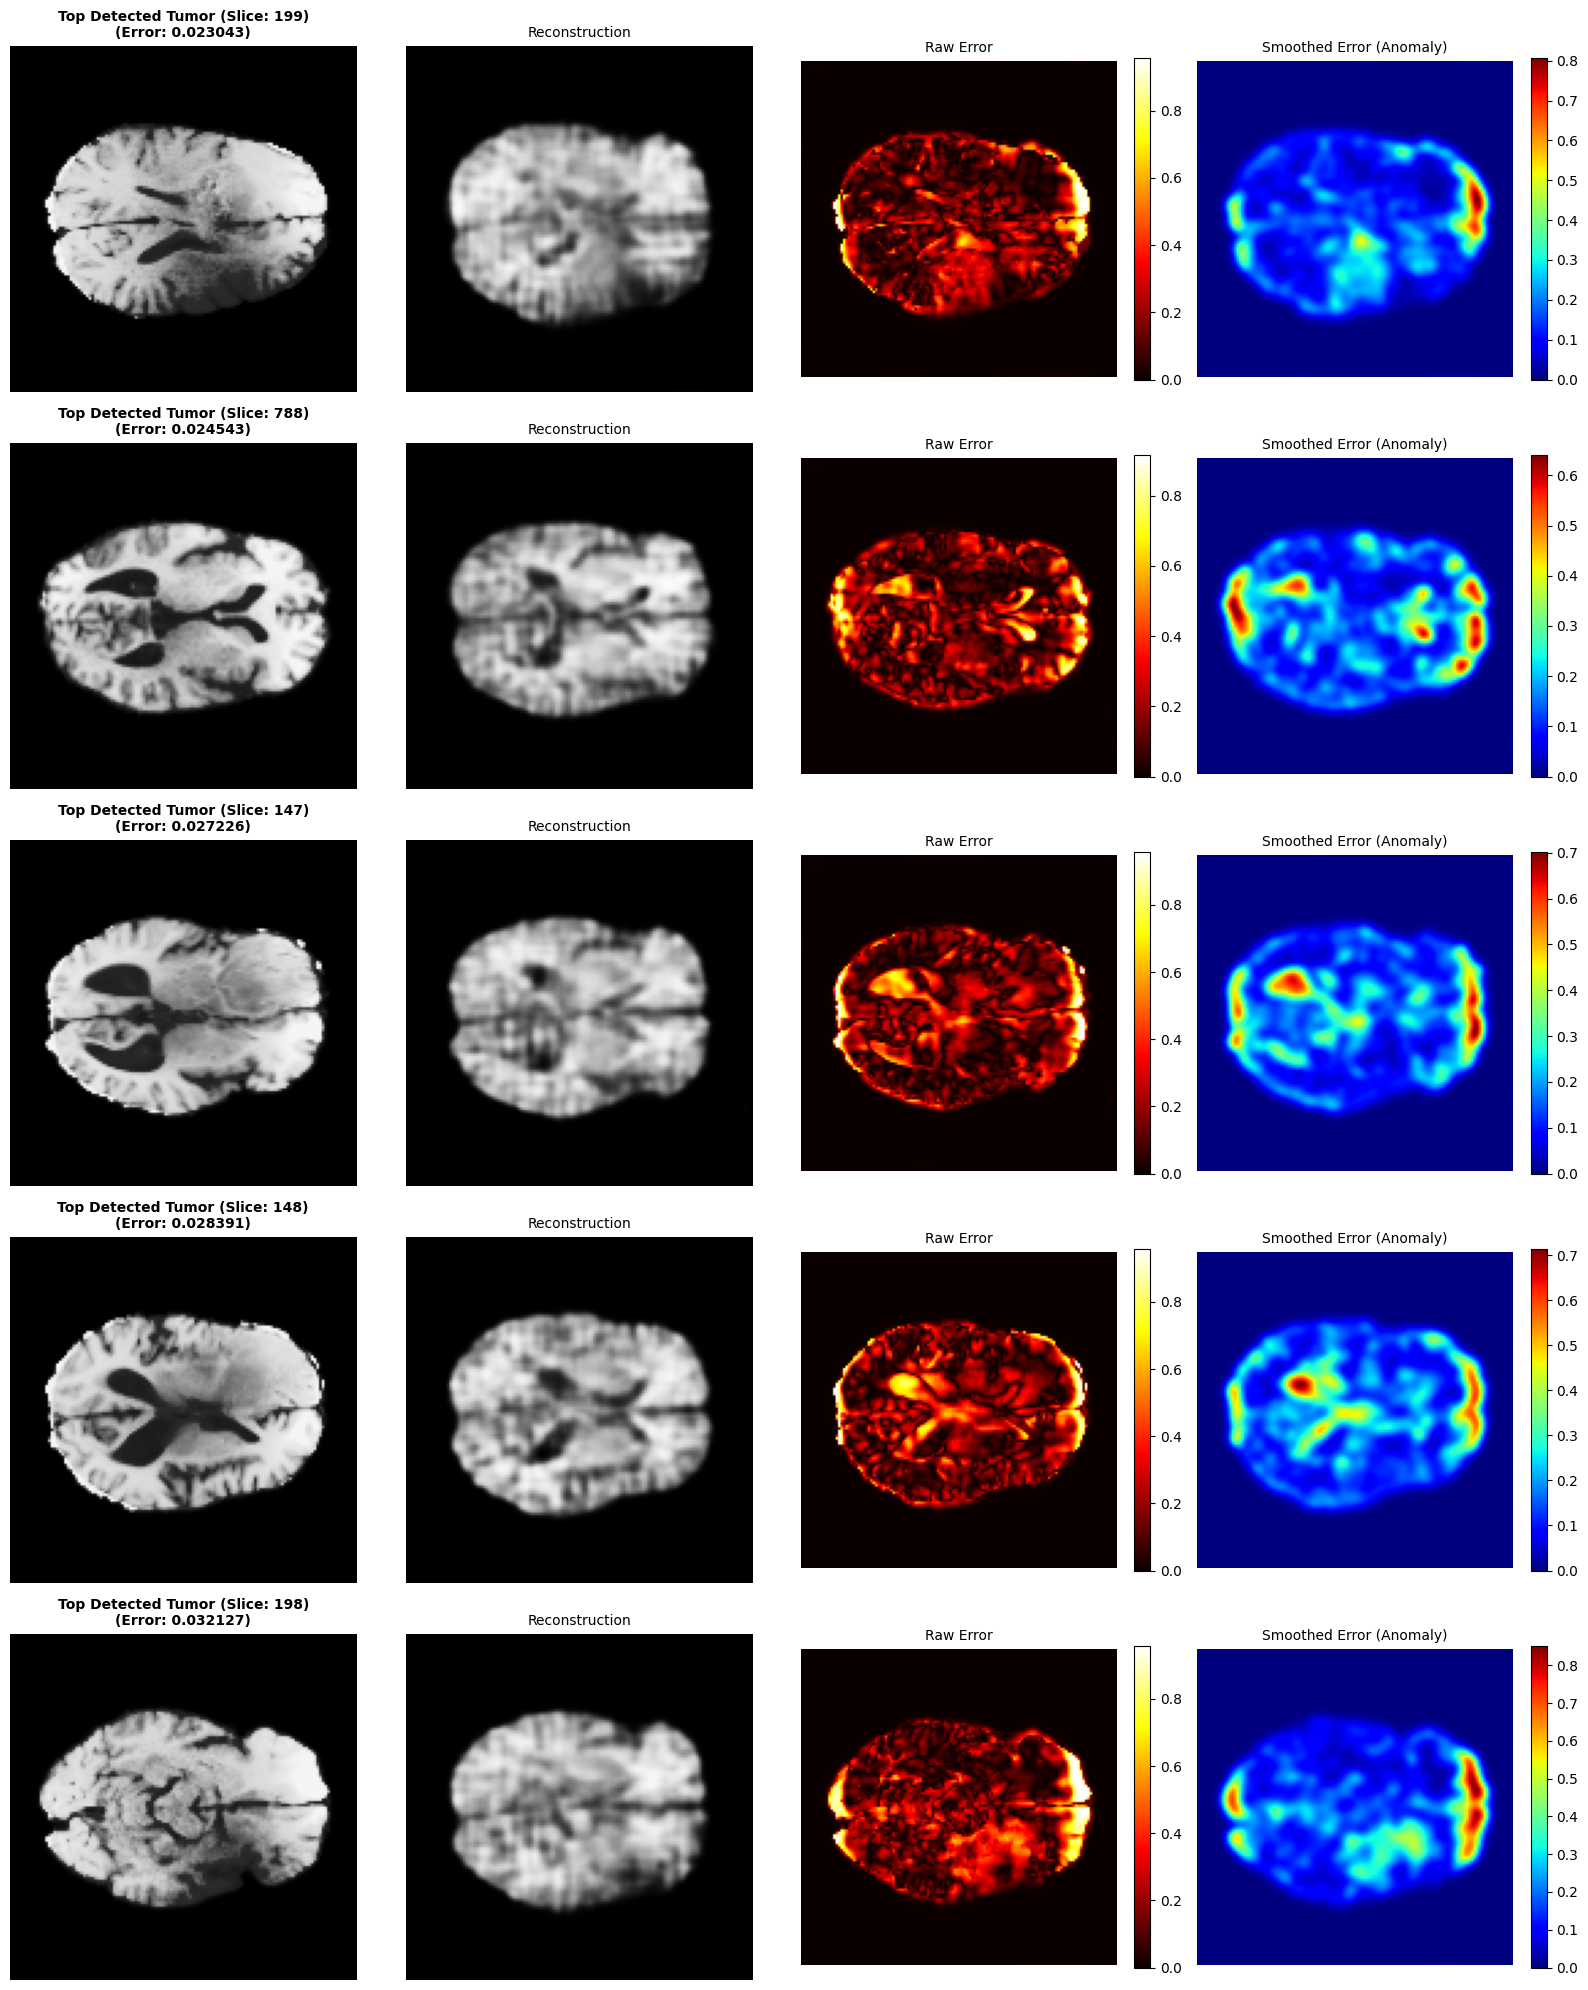


 Evidence Saved to Drive!


In [27]:
# Visualizing Top Detected Tumors
print("\n\u25B6 Visualizing Top Detected Tumors...")

# Ensure worst_anomaly_indices is defined, which it should be after evaluation
# If running this cell independently, ensure 'anomaly_errors' and 'test_dataset' are available

# Assuming worst_anomaly_indices is available from the evaluation step
# It contains indices of images with the highest reconstruction error in the test_dataset
worst_anomalies = worst_anomaly_indices[:5] # Taking the top 5 worst anomalies

visualize_extremes_with_smoothed_error(
    model,
    test_dataset,
    worst_anomalies,
    anomaly_errors, # Use anomaly_errors to get the scores for these indices
    "Top Detected Tumor",
    "ecnn_optimized_top_tumors.png"
)

print("\n Evidence Saved to Drive!")

🔍 Visualizing 5 Random Test Slices with Scores...


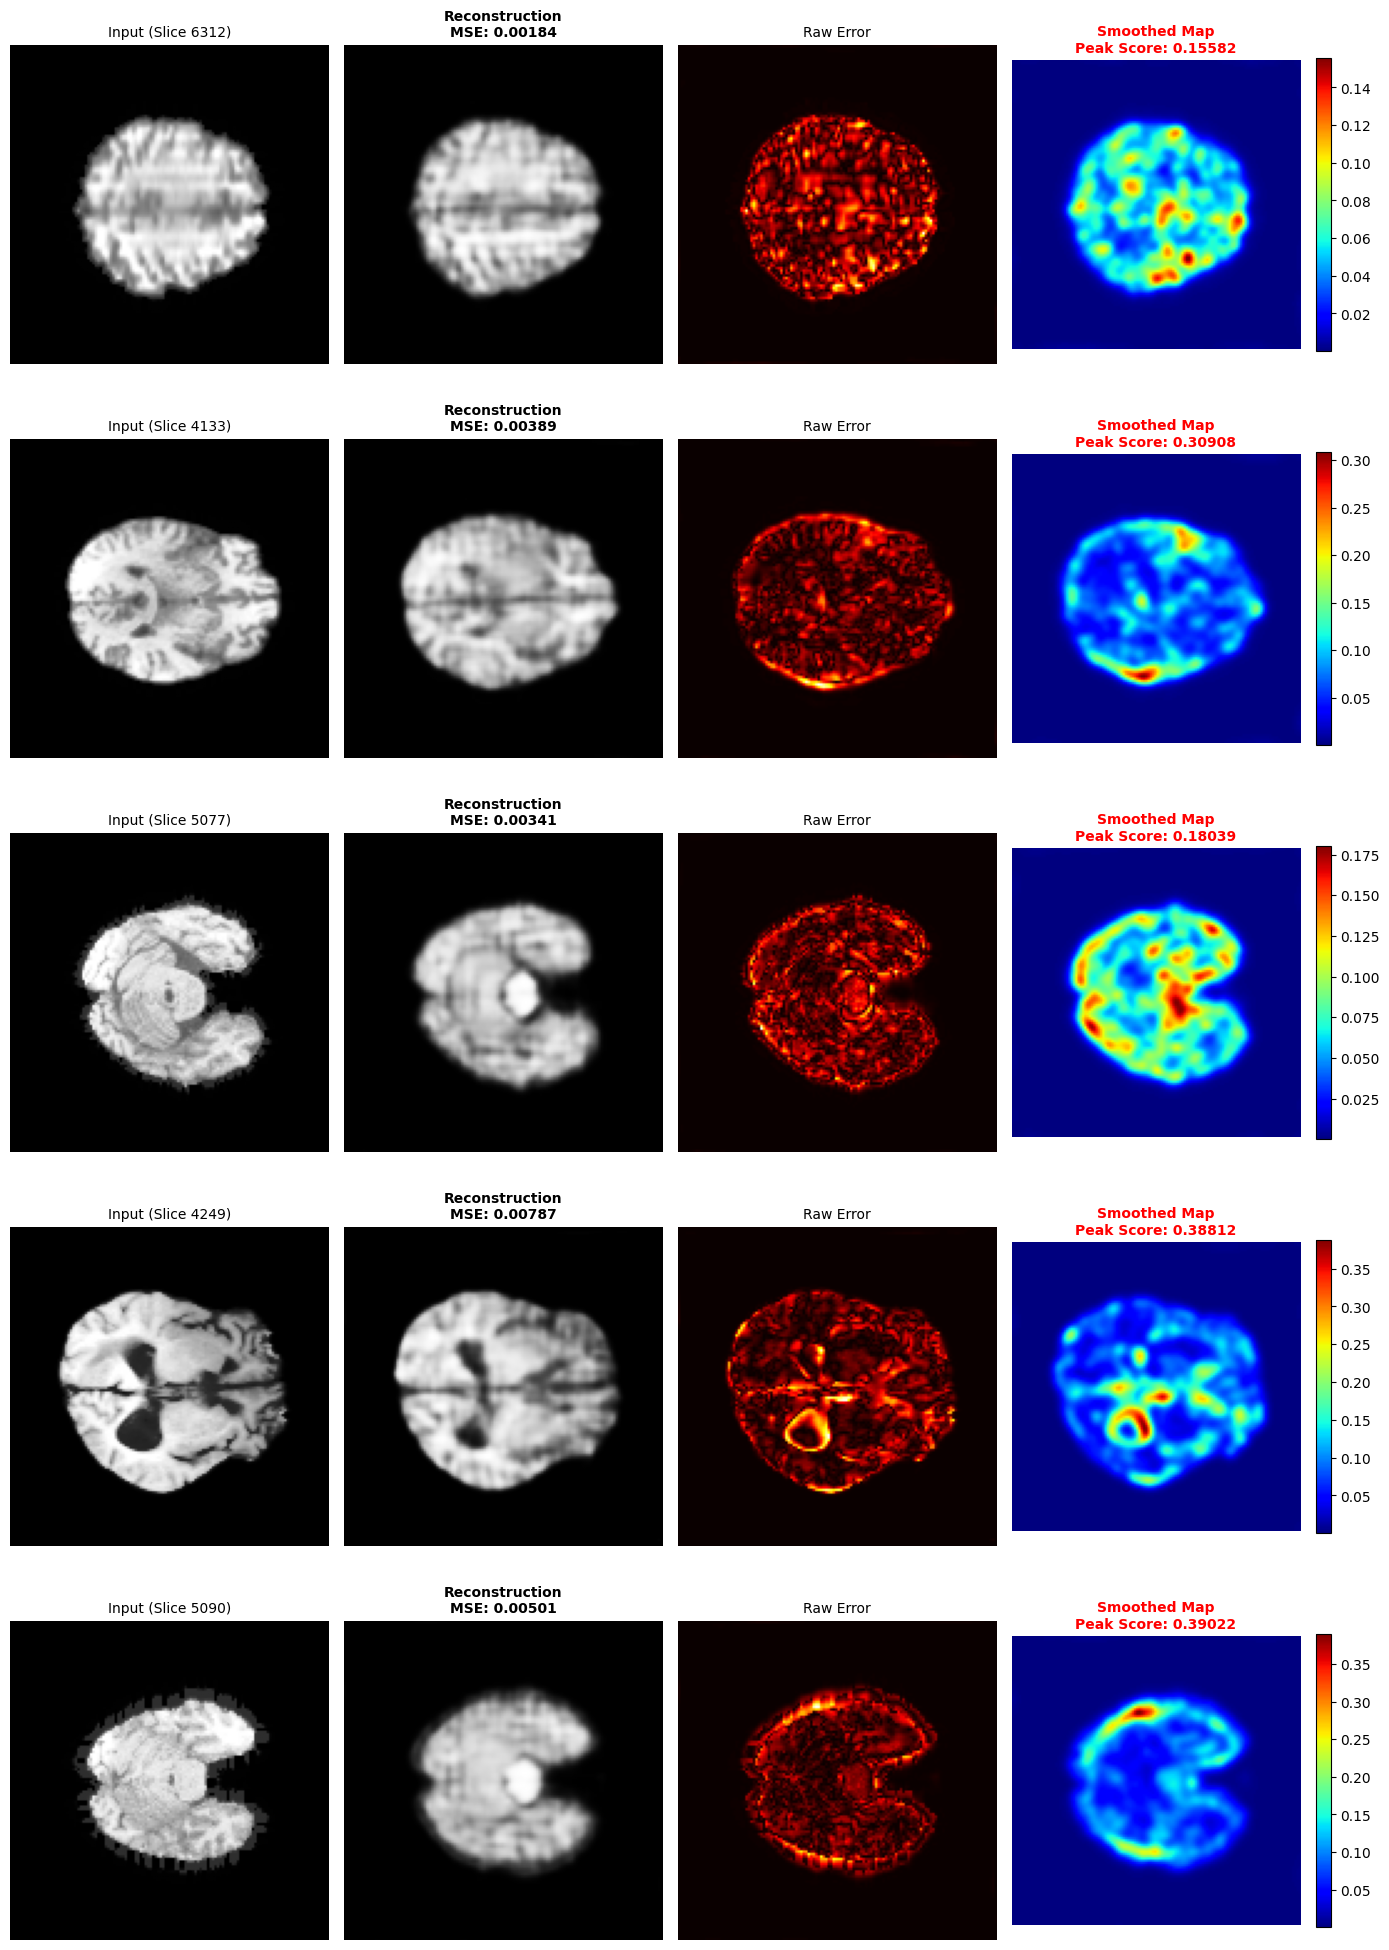

In [19]:
# ==========================================
#  RANDOM SLICE VISUALIZATION (WITH ERROR SCORES)
# ==========================================
import random

def visualize_random_slices_with_score(model, dataset, num_samples=5, sigma=2):
    model.eval()

    # Pick random indices
    total_len = len(dataset)
    indices = random.sample(range(total_len), num_samples)

    print(f"🔍 Visualizing {num_samples} Random Test Slices with Scores...")

    plt.figure(figsize=(14, 4 * len(indices)))

    for i, idx in enumerate(indices):
        input_tensor, _ = dataset[idx]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            recon = model(input_tensor)

        img = input_tensor.cpu().numpy().squeeze()
        rec = recon.cpu().numpy().squeeze()
        diff = np.abs(img - rec)

        # Calculate Scores
        mse_val = np.mean(diff ** 2)
        diff_smooth = ndimage.gaussian_filter(diff, sigma=sigma)
        peak_anomaly = np.max(diff_smooth)

        # Plot
        # 1. Input
        plt.subplot(len(indices), 4, i*4 + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Input (Slice {idx})", fontsize=10)
        plt.axis('off')

        # 2. Reconstruction
        plt.subplot(len(indices), 4, i*4 + 2)
        plt.imshow(rec, cmap='gray')
        plt.title(f"Reconstruction\nMSE: {mse_val:.5f}", fontsize=10, fontweight='bold')
        plt.axis('off')

        # 3. Raw Error
        plt.subplot(len(indices), 4, i*4 + 3)
        plt.imshow(diff, cmap='hot')
        plt.title("Raw Error", fontsize=10)
        plt.axis('off')

        # 4. Smoothed Error
        plt.subplot(len(indices), 4, i*4 + 4)
        im = plt.imshow(diff_smooth, cmap='jet')
        plt.title(f"Smoothed Map\nPeak Score: {peak_anomaly:.5f}", fontsize=10, fontweight='bold', color='red')
        plt.axis('off')
        plt.colorbar(im, fraction=0.046)

    plt.tight_layout()
    plt.show()

# Run it
visualize_random_slices_with_score(model, test_dataset, num_samples=5, sigma=2)

In [ ]:
# ==========================================
# PRIMARY-POLICY EVALUATION (Aligned with other notebooks)
# Score: mean squared reconstruction error
# Threshold: FPR@20% from NORMAL (val) scores only
# Brain-mask scoring: enabled (mask = input > 0.01, min pixels = 50)
# ==========================================
import os
import sys
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm

# --- Required Imports for ECNNAutoencoderV3 ---
import torch.nn as nn
from e2cnn import gspaces
from e2cnn import nn as e2nn
# ------------------------------------------------

# ========================================== # Added from cell 93e6c93b
# E(n)-EQUIVARIANT ARCHITECTURE (V3 FINAL: 11M PARAM MATCH)
# ==========================================
class ECNNAutoencoderV3(nn.Module):
    """
    The 'Champion' Architecture (Final Match).
    1. Enforces C4 Rotational Symmetry.
    2. Enforces Information Bottleneck.
    3. SCALED UP to ~11 Million Parameters (Wide Channels + 1024 Latent).
    """
    def __init__(self, latent_dim=1024):  # <--- CHANGED TO 1024 to hit ~11M params
        super(ECNNAutoencoderV3, self).__init__()

        # 1. Define the Symmetry Group
        self.r2_act = gspaces.Rot2dOnR2(N=4)
        self.in_type = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])

        # 2. WIDE Feature Fields
        # We use 32, 64, 128, 256 FIELDS (x4 for effective channels)
        self.type_128 = e2nn.FieldType(self.r2_act, 32*[self.r2_act.regular_repr])  # 128 ch
        self.type_256 = e2nn.FieldType(self.r2_act, 64*[self.r2_act.regular_repr])  # 256 ch
        self.type_512 = e2nn.FieldType(self.r2_act, 128*[self.r2_act.regular_repr]) # 512 ch
        self.type_1024 = e2nn.FieldType(self.r2_act, 256*[self.r2_act.regular_repr]) # 1024 ch

        # --- ENCODER ---
        self.encoder = nn.Sequential(
            # 1 -> 128 channels
            e2nn.R2Conv(self.in_type, self.type_128, kernel_size=7, padding=3, stride=2),
            e2nn.InnerBatchNorm(self.type_128), e2nn.ReLU(self.type_128),

            # 128 -> 256
            e2nn.R2Conv(self.type_128, self.type_256, kernel_size=3, padding=1, stride=2),
            e2nn.InnerBatchNorm(self.type_256), e2nn.ReLU(self.type_256),

            # 256 -> 512
            e2nn.R2Conv(self.type_256, self.type_512, kernel_size=3, padding=1, stride=2),
            e2nn.InnerBatchNorm(self.type_512), e2nn.ReLU(self.type_512),

            # 512 -> 1024
            e2nn.R2Conv(self.type_512, self.type_1024, kernel_size=3, padding=1, stride=2),
            e2nn.InnerBatchNorm(self.type_1024), e2nn.ReLU(self.type_1024),

            # 1024 -> 1024 (4x4 spatial)
            e2nn.PointwiseMaxPool(self.type_1024, kernel_size=2, stride=2)
        )

        # --- BOTTLENECK ---
        self.group_pool = e2nn.GroupPooling(self.type_1024)

        # Flat Dim: 256 fields * 4 * 4 spatial = 4096 features
        self.flat_dim = 256 * 4 * 4

        # Linear Layers (The Heavy Lifters for Param Count)
        # 4096 -> 1024 (approx 4.2M params)
        self.fc_encode = nn.Linear(self.flat_dim, latent_dim)
        # 1024 -> 4096 (approx 4.2M params)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # --- DECODER ---
        self.up1 = self._up_block(self.type_1024, self.type_512)
        self.up2 = self._up_block(self.type_512, self.type_256)
        self.up3 = self._up_block(self.type_256, self.type_128)

        self.final_conv = e2nn.R2Conv(self.type_128, self.in_type, kernel_size=3, padding=1)
        self.sigmoid = nn.Sigmoid()

    def _up_block(self, in_type, out_type):
        return nn.Sequential(
            e2nn.R2Conv(in_type, out_type, kernel_size=3, padding=1),
            e2nn.InnerBatchNorm(out_type), e2nn.ReLU(out_type)
        )

    def forward(self, x):
        # 1. Encode
        x_geo = e2nn.GeometricTensor(x, self.in_type)
        features = self.encoder(x_geo)

        # 2. Flatten (Bottleneck)
        invariant = self.group_pool(features)
        batch_size = invariant.tensor.size(0)
        flat = invariant.tensor.view(batch_size, -1)

        z = self.fc_encode(flat)

        # 3. Decode
        z_expand = self.fc_decode(z)
        z_view = z_expand.view(-1, 256, 4, 4) # 256 invariant fields

        # Expand Invariant (256) -> Regular (1024 channels)
        x_recon = e2nn.GeometricTensor(z_view.repeat(1, 4, 1, 1), self.type_1024)

        # 4 -> 8
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = e2nn.GeometricTensor(x_recon, self.type_1024)

        # 8 -> 16
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = self.up1(e2nn.GeometricTensor(x_recon, self.type_1024))

        # 16 -> 32
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = self.up2(e2nn.GeometricTensor(x_recon, self.type_512))

        # 32 -> 64
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = self.up3(e2nn.GeometricTensor(x_recon, self.type_256))

        # 64 -> 128
        x_recon = nn.functional.interpolate(x_recon.tensor, scale_factor=2, mode='bilinear')
        x_recon = self.final_conv(e2nn.GeometricTensor(x_recon, self.type_128))

        return self.sigmoid(x_recon.tensor)

    def get_latent(self, x):
        x_geo = e2nn.GeometricTensor(x, self.in_type)
        features = self.encoder(x_geo)
        invariant = self.group_pool(features)
        flat = invariant.tensor.view(invariant.tensor.size(0), -1)
        return self.fc_encode(flat)

# =======================================================

# Try to import shared metric utilities from repo; fallback if unavailable
def _threshold_from_normal_scores(normal_scores, target_fpr=0.20):
    normal_scores = np.asarray(normal_scores, dtype=np.float32)
    if normal_scores.size == 0:
        return np.nan
    return float(np.percentile(normal_scores, (1.0 - float(target_fpr)) * 100.0))

def _compute_full_metrics(y_true, y_scores, threshold):
    from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
    y_true = np.asarray(y_true).astype(int)
    y_scores = np.asarray(y_scores).astype(float)
    y_pred = (y_scores >= float(threshold)).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
        'f1_score': float(f1_score(y_true, y_pred, zero_division=0)),
        'auroc': float(roc_auc_score(y_true, y_scores)) if np.unique(y_true).size > 1 else np.nan,
        'auprc': float(average_precision_score(y_true, y_scores)) if np.unique(y_true).size > 1 else np.nan,
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
        'fpr': float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        'fnr': float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
        'total_samples': int(y_true.size),
        'total_positive': int((y_true == 1).sum()),
        'total_negative': int((y_true == 0).sum()),
    }
    return out

try:
    # If repo path is available, use shared implementations
    if 'REPO_ROOT' in globals():
        evals_dir = os.path.join(str(REPO_ROOT), 'notebooks', 'evals')
        if os.path.exists(evals_dir) and evals_dir not in sys.path:
            sys.sys.path.insert(0, evals_dir)
    from metrics_utils import threshold_from_normal_scores as _shared_threshold
    from metrics_utils import compute_full_metrics as _shared_full_metrics
    _threshold_from_normal_scores = _shared_threshold
    _compute_full_metrics = _shared_full_metrics
    print('Using shared metrics_utils pipeline functions.')
except Exception:
    print('Using local fallback metric helpers.')

TARGET_FPR = 0.20
ERROR_MODE = 'squared'
USE_BRAIN_MASK = True
MIN_BRAIN_PIXELS = 50

@torch.no_grad()
def compute_primary_scores(model, dataloader, device, use_brain_mask=True, min_brain_pixels=50, error_mode='squared'):
    model.eval()
    scores = []

    for x, _ in tqdm(dataloader, desc='Computing primary-policy scores'):
        x = x.to(device)
        recon = model(x)

        # Keep shape-safe behavior
        if recon.shape[-2:] != x.shape[-2:]:
            recon = F.interpolate(recon, size=x.shape[-2:], mode='bilinear', align_corners=False)

        diff = (x - recon)
        err = diff.pow(2) if error_mode == 'squared' else diff.abs()

        if not use_brain_mask:
            batch_scores = err.view(err.size(0), -1).mean(dim=1)
            scores.extend(batch_scores.detach().cpu().numpy().tolist())
            continue

        x_np = x.detach().cpu().numpy()[:, 0]
        err_np = err.detach().cpu().numpy()[:, 0]

        for i in range(err_np.shape[0]):
            brain_mask = (x_np[i] > 0.01)
            if int(brain_mask.sum()) < int(min_brain_pixels):
                continue
            scores.append(float(err_np[i][brain_mask].mean()))

    return np.asarray(scores, dtype=np.float32)

# Ensure best checkpoint is loaded for final evaluation
ckpt_path = f'{MODEL_PATH}/ecnn_optimized_best.pth'
checkpoint = torch.load(ckpt_path, map_location=device)

# FIX: Re-instantiate the model if it's not defined in the current scope.
# This might happen if the runtime was restarted after model definition.
# The ECNNAutoencoderV3 class and 'device' variable are expected to be available
# from previous cell executions.
if 'model' not in globals():
    model = ECNNAutoencoderV3().to(device)

model.load_state_dict(checkpoint['model_state_dict'], strict=False)
model.eval()

print('\nRunning aligned primary-policy evaluation...')
normal_scores = compute_primary_scores(
    model, val_loader, device,
    use_brain_mask=USE_BRAIN_MASK,
    min_brain_pixels=MIN_BRAIN_PIXELS,
    error_mode=ERROR_MODE,
    )
anomaly_scores = compute_primary_scores(
    model, test_loader, device,
    use_brain_mask=USE_BRAIN_MASK,
    min_brain_pixels=MIN_BRAIN_PIXELS,
    error_mode=ERROR_MODE,
    )

threshold = _threshold_from_normal_scores(normal_scores, target_fpr=TARGET_FPR)
y_true = np.concatenate([np.zeros(len(normal_scores), dtype=int), np.ones(len(anomaly_scores), dtype=int)])
y_scores = np.concatenate([normal_scores, anomaly_scores])
metrics = _compute_full_metrics(y_true, y_scores, threshold)

aligned_results = {
    'model_name': 'ECNN-AE (Optimized)',
    'checkpoint_path': ckpt_path,
    'score_method': 'mean',
    'threshold_method': 'fpr',
    'target_fpr': TARGET_FPR,
    'error_mode': ERROR_MODE,
    'use_brain_mask_for_scoring': USE_BRAIN_MASK,
    'min_brain_pixels': MIN_BRAIN_PIXELS,
    'batch_size': int(BATCH_SIZE) if 'BATCH_SIZE' in globals() else None,
    'threshold': float(threshold),
    'normal_count': int(len(normal_scores)),
    'anomaly_count': int(len(anomaly_scores)),
    'normal_mean': float(np.mean(normal_scores)),
    'normal_std': float(np.std(normal_scores)),
    'anomaly_mean': float(np.mean(anomaly_scores)),
    'anomaly_std': float(np.std(anomaly_scores)),
    **{k: float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v for k, v in metrics.items()}
}

print('\n=== ALIGNED PRIMARY-POLICY METRICS ===')
for k in ['auroc','auprc','accuracy','precision','recall','specificity','f1_score','fpr','fnr','threshold']:
    print(f"{k}: {aligned_results.get(k)}")
print(f"TP={aligned_results['tp']}, TN={aligned_results['tn']}, FP={aligned_results['fp']}, FN={aligned_results['fn']}")

# Save outputs
os.makedirs(RESULTS_PATH, exist_ok=True)
json_out = f'{RESULTS_PATH}/ecnn_optimized_primary_policy_metrics.json'
csv_out = f'{RESULTS_PATH}/ecnn_optimized_primary_policy_metrics.csv'
np.save(f'{RESULTS_PATH}/ecnn_optimized_primary_policy_normal_scores.npy', normal_scores)
np.save(f'{RESULTS_PATH}/ecnn_optimized_primary_policy_anomaly_scores.npy', anomaly_scores)
with open(json_out, 'w', encoding='utf-8') as f:
    json.dump(aligned_results, f, indent=2)
pd.DataFrame([aligned_results]).to_csv(csv_out, index=False)
print(f'\nSaved: {json_out}')
print(f'Saved: {csv_out}')

Using local fallback metric helpers.
/usr/local/lib/python3.12/dist-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)

Running aligned primary-policy evaluation...
Computing primary-policy scores: 100%|██████████| 58/58 [00:03<00:00, 15.02it/s]
Computing primary-policy scores: 100%|██████████| 122/122 [00:06<00:00, 18.78it/s]

=== ALIGNED PRIMARY-POLICY METRICS ===
auroc: 0.8871942560640771
auprc: 0.934916953070938
accuracy: 0.8018521754324655
precision: 0.8953921007441328
recall: 0.8027970233512959
specificity: 0.7998357064622125
f1_score: 0.8465701528886483
fpr: 0.2001642935377875
fnr: 0.19720297664870412
threshold: 0.008510652929544449
TP=6257, TN=2921, FP=731, FN=1537

Saved: /content/drive/MyDrive/symAD-ECNN/results/copy_ecnn_optimized/ecnn_optimized_primary_policy_metrics.json
Saved: /content/drive/MyDrive/symAD-ECNN/results/copy_ecnn_optimized/ecnn_optimized_primary_policy_metrics.csv